In [ ]:
# Paso 1: Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


###modelo solo con v-dem y el primer paper

In [ ]:
import pandas as pd

file_path = "/content/drive/My Drive/Verano25/GOETHE/Proyecto/mergedataini.csv"
df_vdem = pd.read_csv(file_path, encoding="latin1")
df_vdem.head()


/tmp/ipython-input-2-1401212077.py:4: DtypeWarning: Columns (20,21,374,382,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,879) have mixed types. Specify dtype option on import or set low_memory=False.
  df_vdem = pd.read_csv(file_path, encoding="latin1")


,countrycode,countryname,region,regionname,adminregion,adminregionname,incomelevel,incomelevelname,lendingtype,lendingtypename,...,v2exbribe,v2jucomp,v2mecrit,v2mecenefm,v2cacamps,v2clkill,v2cltort,v2clacjstm,v2exrescon,v2regimpgroup
0,USA,United States,NAC,North America,NaN,NaN,HIC,High income,LNX,Not classified,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,USA,United States,NAC,North America,NaN,NaN,HIC,High income,LNX,Not classified,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,USA,United States,NAC,North America,NaN,NaN,HIC,High income,LNX,Not classified,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,USA,United States,NAC,North America,NaN,NaN,HIC,High income,LNX,Not classified,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,USA,United States,NAC,North America,NaN,NaN,HIC,High income,LNX,Not classified,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_vdem["year"] = pd.to_numeric(df_vdem["year"], errors="coerce").astype("Int64")

# df_vdem_latam["year"] = pd.to_numeric(df_vdem["year"], errors="coerce").astype("Int64")


In [ ]:
# print(sorted(df_vdem["year"].dropna().unique()))
# print(df_vdem["year"].value_counts().sort_index())




In [ ]:

# # # 1. Copiar base
# # df_vdem = df_vdem.copy()
# # df_vdem["countrycode"] = df_vdem["countrycode"].astype(str)
# # df_vdem["year"] = pd.to_numeric(df_vdem["year"], errors="coerce").astype("Int64")

# # # 2. Crear variables de interacción
# # df_vdem["polityXcorruption"] = df_vdem["polity2"] * df_vdem["wbgi_ccn"]
# # df_vdem["ruleXcorruption"] = df_vdem["v2x_rule"] * df_vdem["wbgi_ccn"]
# # df_vdem["participationXcorruption"] = df_vdem["v2x_partip"] * df_vdem["wbgi_ccn"]

# # # 3. Variables seleccionadas
# # vars_modelo = [
# #     "v2x_polyarchy", "v2x_partip", "v2x_libdem", "v2x_rule",  # V-Dem
# #     "wbgi_ccn", "wbgi_rln",                                   # WGI
# #     "polity2",                                                # Polity
# #     "polityXcorruption", "ruleXcorruption", "participationXcorruption",  # Interacciones
# #     "lnwdi_pop"                                               # Control
# # ]


# #######
# # 1. Copiar base y asegurar tipos
# df_vdem = df_vdem.copy()
# df_vdem["countrycode"] = df_vdem["countrycode"].astype(str)
# df_vdem["year"] = pd.to_numeric(df_vdem["year"], errors="coerce").astype("Int64")

# # 2. Centrar variables base (restar la media)
# df_vdem["v2x_partip_c"] = df_vdem["v2x_partip"] - df_vdem["v2x_partip"].mean()
# df_vdem["v2x_rule_c"] = df_vdem["v2x_rule"] - df_vdem["v2x_rule"].mean()
# df_vdem["wbgi_ccn_c"] = df_vdem["wbgi_ccn"] - df_vdem["wbgi_ccn"].mean()
# df_vdem["polity2_c"] = df_vdem["polity2"] - df_vdem["polity2"].mean()

# # 3. Crear variables de interacción con variables centradas
# df_vdem["polityXcorruption"] = df_vdem["polity2_c"] * df_vdem["wbgi_ccn_c"]
# df_vdem["ruleXcorruption"] = df_vdem["v2x_rule_c"] * df_vdem["wbgi_ccn_c"]
# df_vdem["participationXcorruption"] = df_vdem["v2x_partip_c"] * df_vdem["wbgi_ccn_c"]

# # 4. Variables seleccionadas (usa las centradas en lugar de las originales)
# vars_modelo = [
#     "v2x_partip_c", "v2x_rule_c", "wbgi_ccn_c",
#     "polity2_c", "polityXcorruption", "ruleXcorruption",
#     "participationXcorruption", "lnwdi_pop"
# ]



In [ ]:
import numpy as np
import pandas as pd
import difflib

vdem_vars = [
    "v2x_partip", "v2x_rule", "v2x_polyarchy", "v2x_libdem"
]

wgi_vars = [
    "wbgi_ccn", "wbgi_rln"
]

polity_vars = [
    "polity2"
]

control_vars = [
    "lnwdi_pop"
]

# Variables necesarias (centradas o interacciones)
vars_necesarias = [
    "v2x_partip", "v2x_rule", "wbgi_ccn", "polity2", "lnwdi_pop"
]

# 1. Combinar todas las variables predictoras
all_predictors = (
    vdem_vars +
    wgi_vars +
    polity_vars +
    control_vars
)

# 2. Copiar base y asegurar tipos
df_vdem = df_vdem.copy()
df_vdem["countrycode"] = df_vdem["countrycode"].astype(str)
df_vdem["year"] = pd.to_numeric(df_vdem["year"], errors="coerce").astype("Int64")

# 3. Centrar variables numéricas (excluyendo dummies, si los hubiera)
vars_a_centrar = [
    col for col in all_predictors
    if df_vdem[col].dtype in [np.float64, np.int64]
]

for col in vars_a_centrar:
    df_vdem[col + "_c"] = df_vdem[col] - df_vdem[col].mean()

# 4. Asegurar que las vars_necesarias estén centradas
for var in vars_necesarias:
    if var + "_c" not in df_vdem.columns:
        if var in df_vdem.columns:
            df_vdem[var + "_c"] = df_vdem[var] - df_vdem[var].mean()
        else:
            similares = difflib.get_close_matches(var, df_vdem.columns, n=2, cutoff=0.6)
            print(f" '{var}' no existe. ¿Similares?: {similares}")

# 5. Crear interacciones
interactions = {
    'polityXcorruption':        ('polity2_c', 'wbgi_ccn_c'),
    'ruleXcorruption':          ('v2x_rule_c', 'wbgi_ccn_c'),
    'participationXcorruption': ('v2x_partip_c', 'wbgi_ccn_c')
}

interaction_vars = []
for name, (var1, var2) in interactions.items():
    if var1 in df_vdem.columns and var2 in df_vdem.columns:
        df_vdem[name] = df_vdem[var1] * df_vdem[var2]
        interaction_vars.append(name)
    else:
        print(f" No se pudo crear {name} porque falta '{var1}' o '{var2}'.")

# 6. Construir lista final de columnas
columns_centered_final = [col + "_c" for col in vars_a_centrar] + interaction_vars



In [ ]:
columns_centered_final

['v2x_partip_c',
 'v2x_rule_c',
 'v2x_polyarchy_c',
 'v2x_libdem_c',
 'wbgi_ccn_c',
 'wbgi_rln_c',
 'polity2_c',
 'lnwdi_pop_c',
 'polityXcorruption',
 'ruleXcorruption',
 'participationXcorruption']

In [ ]:
# latam_countries = [
#     "argentina", "bolivia", "brasil", "chile", "colombia", "costa rica",
#     "cuba", "republica dominicana", "ecuador", "el salvador", "guatemala",
#     "honduras", "haiti", "mexico", "nicaragua", "panama", "paraguay",
#     "peru", "uruguay", "venezuela"
# ]


# Asegúrate de que las columnas 'year' y 'country_name' existen en tu DataFrame
df_vdem["country_name"] = df_vdem["country_name"].str.lower().str.strip()
df_vdem["year"] = pd.to_numeric(df_vdem["year"], errors="coerce")  # por si acaso

# Filtrar por años y países de LATAM
df_vdem_latam = df_vdem[
    (df_vdem["year"].between(2014, 2020)) &
    (df_vdem["regionname"] == 'Latin America and Caribbean')
]

df_vdem = df_vdem[df_vdem["year"].between(2014, 2020)]



#2014-2020 -- FDhrdkill

In [ ]:
print(sorted(df_vdem["year"].dropna().unique()))


[np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Definir variables del modelo
# vars_modelo = [
#     "v2x_polyarchy", "v2x_partip", "v2x_libdem", "v2x_rule",  # V-Dem
#     "wbgi_ccn", "wbgi_rln",                                   # WGI
#     "polity2",                                                # Polity
#     "polityXcorruption", "ruleXcorruption", "participationXcorruption",  # Interacciones
#     "lnwdi_pop"                                               # Control
# ]

# 2. Crear matriz X solo con esas variables
X_vif = df_vdem[columns_centered_final].copy()

# 3. Reemplazar infinitos y NaN
X_vif = X_vif.replace([np.inf, -np.inf], np.nan)
X_vif = X_vif.fillna(X_vif.mean())

# 4. Eliminar columnas constantes
X_vif = X_vif.loc[:, X_vif.std() > 0]

# 5. Agregar constante
X_vif = sm.add_constant(X_vif)

# 6. Calcular VIF
vif_df = pd.DataFrame()
vif_df["variable"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# 7. Mostrar resultados
print("VIF de las variables seleccionadas:")
print(vif_df)


✅ VIF de las variables seleccionadas:
                    variable        VIF
0                      const   3.395168
1               v2x_partip_c   4.079829
2                 v2x_rule_c   7.448093
3            v2x_polyarchy_c  36.193089
4               v2x_libdem_c  48.358598
5                 wbgi_ccn_c  23.320460
6                 wbgi_rln_c  21.740367
7                  polity2_c   2.617885
8                lnwdi_pop_c   2.366383
9          polityXcorruption   2.537822
10           ruleXcorruption   2.113247
11  participationXcorruption   2.627150


In [ ]:
# print(sorted(df_vdem["year"].dropna().unique()))


[np.int64(2000), np.int64(2001), np.int64(2002)]


In [ ]:
# df_vdem_latam

# 4. Filtrar variables con VIF < 10 (excluyendo la constante)
vif_filtrado = vif_df[(vif_df["VIF"] < 10) & (vif_df["variable"] != "const")]

# 5. Mostrar resultados
print("Variables con VIF < 10:")
print(vif_filtrado)

# 6. Lista limpia de variables seleccionadas
vars_utiles = vif_filtrado["variable"].tolist()
print("\n Lista final de variables sin multicolinealidad fuerte:")
print(vars_utiles)

✅ Variables con VIF < 10:
                    variable       VIF
1               v2x_partip_c  4.079829
2                 v2x_rule_c  7.448093
7                  polity2_c  2.617885
8                lnwdi_pop_c  2.366383
9          polityXcorruption  2.537822
10           ruleXcorruption  2.113247
11  participationXcorruption  2.627150

📌 Lista final de variables sin multicolinealidad fuerte:
['v2x_partip_c', 'v2x_rule_c', 'polity2_c', 'lnwdi_pop_c', 'polityXcorruption', 'ruleXcorruption', 'participationXcorruption']


In [ ]:
# FDhrdkill
# df_mexico = df_vdem.loc[df_vdem["countryname"] == "Mexico", ["year", "FDhrdkill", "countryname"]]
# df_mexico.head()

In [ ]:
# Suponiendo que tienes:
# interactions: dict con interacciones {nombre: (var1, var2)}
# X_vif_reducido: DataFrame con columnas validadas (con VIF bajo)
# interaction_vars: lista con todos los nombres de interacciones posibles (opcional)

# 1. Filtrar interacciones válidas
interacciones_validas = {
    nombre: (var1, var2)
    for nombre, (var1, var2) in interactions.items()
    if var1 in vif_filtrado['variable'] and var2 in vif_filtrado['variable']
}

print(f"Interacciones válidas ({len(interacciones_validas)}):")
print(list(interacciones_validas.keys()))

# 2. Extraer variables base de las interacciones válidas
vars_base = set()
for var1, var2 in interacciones_validas.values():
    vars_base.add(var1)
    vars_base.add(var2)
vars_base = list(vars_base)

# 3. Identificar otras variables en X_vif_reducido que no son bases ni interacciones ni 'const'
otras_vars = [
    var for var in vif_filtrado['variable']
    if var not in vars_base and var not in interacciones_validas.keys() and var != 'const'
    and var not in interaction_vars
]


# 4. Crear lista final de variables para el modelo
variables_modelo = vars_base + list(interacciones_validas.keys()) + otras_vars

print(f"Total variables para modelo: {len(variables_modelo)}")
print(variables_modelo)

# Ahora puedes usar variables_modelo para seleccionar columnas en tu DataFrame:
# X_modelo = df_merged_com[variables_modelo].copy()


Interacciones válidas (0):
[]
Total variables para modelo: 4
['v2x_partip_c', 'v2x_rule_c', 'polity2_c', 'lnwdi_pop_c']


In [ ]:
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import NegativeBinomial, Poisson
from statsmodels.genmod.cov_struct import Autoregressive, Independence, Exchangeable
import statsmodels.api as sm
import numpy as np
import pandas as pd

# Preparar X e y
X = df_vdem[variables_modelo].copy()
X = sm.add_constant(X)
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.mean())
X = X.loc[:, X.std() > 0]

y = df_vdem["FDhrdkill"].replace([np.inf, -np.inf], np.nan).fillna(df_vdem["FDhrdkill"].mean())


#2014-2020 -- FDhrdkill
# Alinear
X = X.loc[y.index]
y = y.loc[X.index]
####

df_model = pd.concat([X, y], axis=1)

# Luego reemplazar los NaN con la media
df_model = df_model.fillna(df_model.mean())

# Eliminar NA por seguridad
X = df_model[X.columns]
y = df_model["FDhrdkill"]

# Grupos y tiempo
groups = df_vdem.loc[X.index, "countrycode"].astype(str).values
time = df_vdem.loc[X.index, "year"].values

# INTENTOS DE MODELO
success = False


model2 = GEE(y, X, groups=groups, time=time, cov_struct=Independence(), family=NegativeBinomial())
result2 = model2.fit()
print(result2.summary())

model3 = GEE(y, X, groups=groups, time=time, cov_struct=Exchangeable(), family=NegativeBinomial())
result3 = model3.fit()
print(result3.summary())



/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                               GEE Regression Results                              
Dep. Variable:                   FDhrdkill   No. Observations:                 1461
Model:                                 GEE   No. clusters:                      195
Method:                        Generalized   Min. cluster size:                   7
                      Estimating Equations   Max. cluster size:                 103
Family:                   NegativeBinomial   Mean cluster size:                 7.5
Dependence structure:         Independence   Num. iterations:                    14
Date:                     Fri, 04 Jul 2025   Scale:                           1.000
Covariance type:                    robust   Time:                         08:04:25
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
v2x_partip_c     5.4271      1.671      3.247      0.001       2.151       8.703
v

In [ ]:
o`

📌 Variables significativas (p < 0.05):
['v2x_partip_c', 'v2x_rule_c', 'lnwdi_pop_c']
📌 Variables significativas (p < 0.05):
['v2x_partip_c', 'v2x_rule_c', 'lnwdi_pop_c']


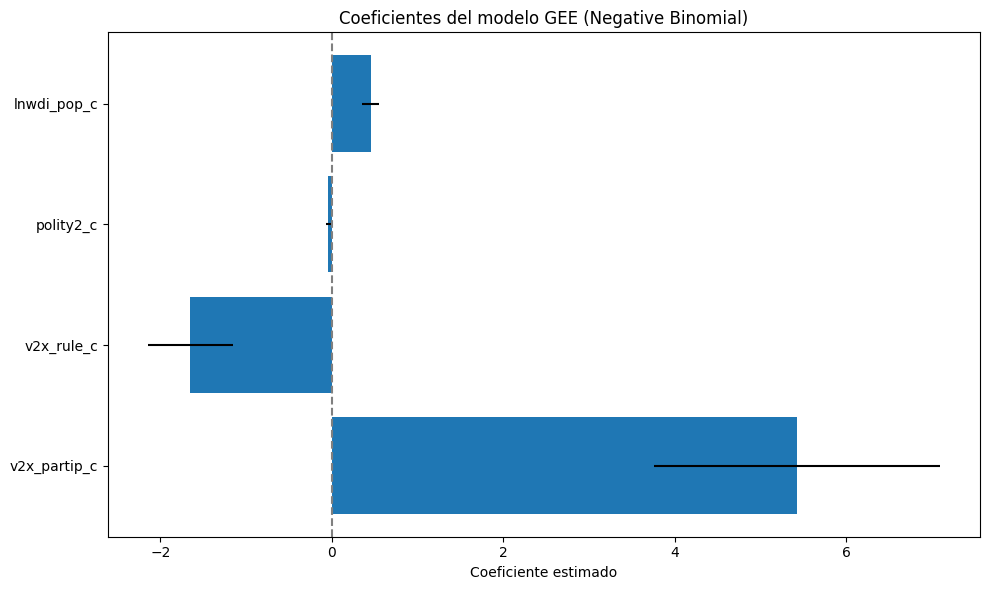

In [ ]:
import matplotlib.pyplot as plt

coefs = result2.params
errors = result2.bse

plt.figure(figsize=(10, 6))
plt.barh(coefs.index, coefs.values, xerr=errors.values)
plt.axvline(x=0, color='gray', linestyle='--')
plt.title("Coeficientes del modelo GEE (Negative Binomial)")
plt.xlabel("Coeficiente estimado")
plt.tight_layout()
plt.show()


In [ ]:
import statsmodels.api as sm

# GLM con Negative Binomial (sin panel)
model_glm = sm.GLM(y, X, family=sm.families.NegativeBinomial())
result_glm = model_glm.fit()

print("\n Comparación de errores estándar (GEE vs GLM):")
comparison = pd.DataFrame({
    "Coef_GEE": result3.params,
    "SE_GEE": result3.bse,
    "Coef_GLM": result_glm.params,
    "SE_GLM": result_glm.bse
})
print(comparison)



🔍 Comparación de errores estándar (GEE vs GLM):
              Coef_GEE    SE_GEE  Coef_GLM    SE_GLM
v2x_partip_c  5.837195  1.683498  5.427101  0.365306
v2x_rule_c   -1.870215  0.438062 -1.650458  0.170269
polity2_c    -0.042122  0.023101 -0.038923  0.011116
lnwdi_pop_c   0.268327  0.058566  0.454007  0.020418


/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


<Axes: xlabel='FLandmanhrdkill', ylabel='Count'>

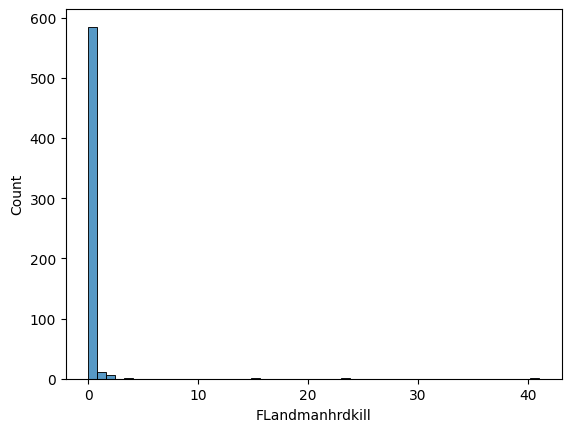

In [ ]:
# import seaborn as sns
# sns.histplot(df_vdem["FLandmanhrdkill"], bins=50)


In [ ]:
# X = df_vdem[vars_reducidas].copy()
# X = sm.add_constant(X)
# X = X.replace([np.inf, -np.inf], np.nan).fillna(X.mean())
# X = X.loc[:, X.std() > 0]


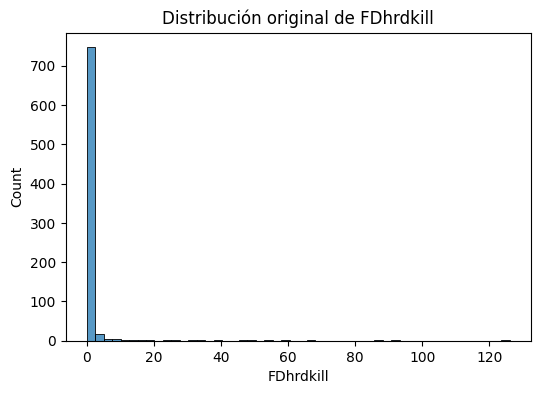

🔍 RMSE: 3.88
🔍 R²: 0.566


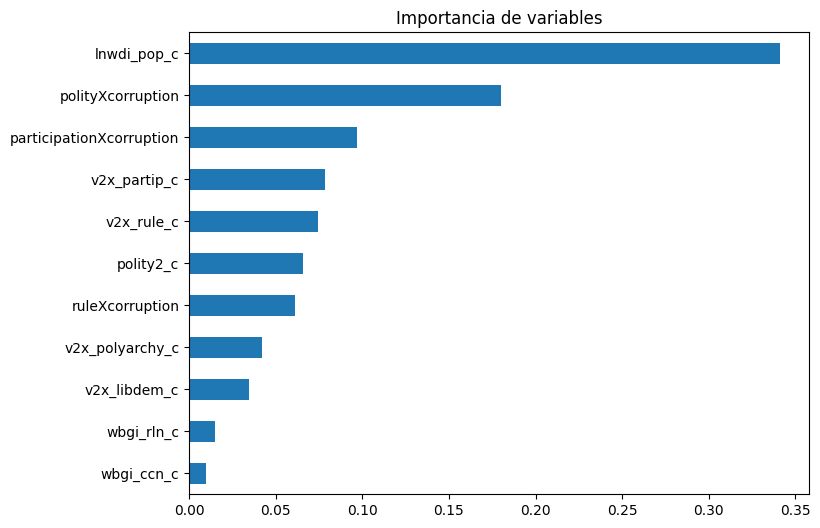

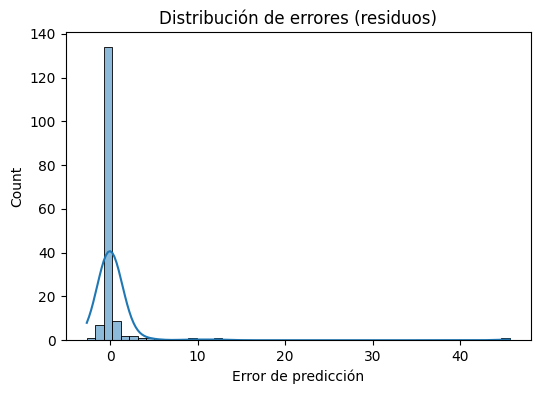

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

# 1. Selección de variables
# vars_reducidas = [v for v in vars_modelo if v != "lnwdi_pop"]

X = df_vdem[columns_centered_final].copy()
y = df_vdem["FDhrdkill"]

X = X.replace([np.inf, -np.inf], np.nan)
y = y.replace([np.inf, -np.inf], np.nan)

df_rf = pd.concat([X, y], axis=1).dropna()
X = df_rf[columns_centered_final]
y = df_rf["FDhrdkill"]

plt.figure(figsize=(6,4))
sns.histplot(y, bins=50, kde=False)
plt.title("Distribución original de FDhrdkill")
plt.show()

y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_log = rf.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)


rmse = sqrt(mean_squared_error(y_test_real, y_pred))
r2 = r2_score(y_test_real, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")


importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(8,6), title="Importancia de variables")
plt.show()

residuals = y_test_real - y_pred
plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Distribución de errores (residuos)")
plt.xlabel("Error de predicción")
plt.show()


###checar outliers

##LATAM

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 2. Crear matriz X solo con esas variables
X_vif = df_vdem_latam[columns_centered_final].copy()

# 3. Reemplazar infinitos y NaN
X_vif = X_vif.replace([np.inf, -np.inf], np.nan)
X_vif = X_vif.fillna(X_vif.mean())

# 4. Eliminar columnas constantes
X_vif = X_vif.loc[:, X_vif.std() > 0]

# 5. Agregar constante
X_vif = sm.add_constant(X_vif)

# 6. Calcular VIF
vif_df = pd.DataFrame()
vif_df["variable"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# 7. Mostrar resultados
print("VIF de las variables seleccionadas:")
print(vif_df)


✅ VIF de las variables seleccionadas:
                    variable        VIF
0                      const   7.756224
1               v2x_partip_c   3.069484
2                 v2x_rule_c  13.505753
3            v2x_polyarchy_c  24.424239
4               v2x_libdem_c  37.082894
5                 wbgi_ccn_c  31.792725
6                 wbgi_rln_c  28.321667
7                  polity2_c   2.820369
8                lnwdi_pop_c   9.635758
9          polityXcorruption   2.739365
10           ruleXcorruption   3.296740
11  participationXcorruption   2.452330


In [ ]:

#Filtrar variables con VIF < 10 (excluyendo la constante)
vif_filtrado = vif_df[(vif_df["VIF"] < 10) & (vif_df["variable"] != "const")]

print("Variables con VIF < 10:")
print(vif_filtrado)

#Lista limpia de variables seleccionadas
vars_utiles = vif_filtrado["variable"].tolist()
print("\n Lista final de variables sin multicolinealidad fuerte:")
print(vars_utiles)

✅ Variables con VIF < 10:
                    variable       VIF
1               v2x_partip_c  3.069484
7                  polity2_c  2.820369
8                lnwdi_pop_c  9.635758
9          polityXcorruption  2.739365
10           ruleXcorruption  3.296740
11  participationXcorruption  2.452330

📌 Lista final de variables sin multicolinealidad fuerte:
['v2x_partip_c', 'polity2_c', 'lnwdi_pop_c', 'polityXcorruption', 'ruleXcorruption', 'participationXcorruption']


In [ ]:
# Suponiendo que tienes:
# interactions: dict con interacciones {nombre: (var1, var2)}
# X_vif_reducido: DataFrame con columnas validadas (con VIF bajo)
# interaction_vars: lista con todos los nombres de interacciones posibles (opcional)

# Filtrar interacciones válidas
interacciones_validas = {
    nombre: (var1, var2)
    for nombre, (var1, var2) in interactions.items()
    if var1 in vif_filtrado['variable'] and var2 in vif_filtrado['variable']
}

print(f"Interacciones válidas ({len(interacciones_validas)}):")
print(list(interacciones_validas.keys()))

# Extraer variables base de las interacciones válidas
vars_base = set()
for var1, var2 in interacciones_validas.values():
    vars_base.add(var1)
    vars_base.add(var2)
vars_base = list(vars_base)

# Identificar otras variables en X_vif_reducido que no son bases ni interacciones ni 'const'
otras_vars = [
    var for var in vif_filtrado['variable']
    if var not in vars_base and var not in interacciones_validas.keys() and var != 'const'
    and var not in interaction_vars
]


variables_modelo = vars_base + list(interacciones_validas.keys()) + otras_vars

print(f"Total variables para modelo: {len(variables_modelo)}")
print(variables_modelo)

# Ahora puedes usar variables_modelo para seleccionar columnas en tu DataFrame:
# X_modelo = df_merged_com[variables_modelo].copy()


Interacciones válidas (0):
[]
Total variables para modelo: 3
['v2x_partip_c', 'polity2_c', 'lnwdi_pop_c']


In [ ]:
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import NegativeBinomial, Poisson
from statsmodels.genmod.cov_struct import Autoregressive, Independence
import statsmodels.api as sm
import numpy as np
import pandas as pd

X = df_vdem_latam[variables_modelo].copy()
X = sm.add_constant(X)
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.mean())
X = X.loc[:, X.std() > 0]

y = df_vdem_latam["FDhrdkill"].replace([np.inf, -np.inf], np.nan).fillna(df_vdem_latam["FDhrdkill"].mean())

X = X.loc[y.index]
y = y.loc[X.index]
####

df_model = pd.concat([X, y], axis=1)

# Luego reemplazar los NaN con la media
df_model = df_model.fillna(df_model.mean())

# Eliminar NA por seguridad
X = df_model[X.columns]
y = df_model["FDhrdkill"]

# Grupos y tiempo
groups = df_vdem_latam.loc[X.index, "countrycode"].astype(str).values
time = df_vdem_latam.loc[X.index, "year"].values

# INTENTOS DE MODELO

print("\nIntento 2: GEE + NegativeBinomial + Independence")

model_latam_2 = GEE(y, X, groups=groups, time=time, cov_struct=Independence(), family=NegativeBinomial())
result2_latam = model_latam_2.fit()
print(result2.summary())

##
# model2 = GEE(y, X, groups=groups, time=time, cov_struct=Exchangable(), family=NegativeBinomial())
# result2 = model2.fit()
# print(result2.summary())

model_latam_3 = GEE(y, X, groups=groups, time=time, cov_struct=Exchangeable(), family=NegativeBinomial())
result3_latam = model_latam_3.fit()
print(result3.summary())



🔹 Intento 2: GEE + NegativeBinomial + Independence
                               GEE Regression Results                              
Dep. Variable:                   FDhrdkill   No. Observations:                 1461
Model:                                 GEE   No. clusters:                      195
Method:                        Generalized   Min. cluster size:                   7
                      Estimating Equations   Max. cluster size:                 103
Family:                   NegativeBinomial   Mean cluster size:                 7.5
Dependence structure:         Independence   Num. iterations:                    14
Date:                     Fri, 04 Jul 2025   Scale:                           1.000
Covariance type:                    robust   Time:                         08:10:50
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
v2x_partip_c     5.4271      1

/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/generalized_estimating_equations.py:1300: IterationLimitWarning: Iteration limit reached prior to convergence
  warnings.warn("Iteration limit reached prior to convergence",


In [ ]:
summary_df_latam = result2_latam.summary2().tables[1]

# Filtrar variables significativas (p < 0.05)
significativas = summary_df_latam[summary_df_latam["P>|z|"] < 0.05]

# Obtener solo los nombres de las variables
lista_significativas = significativas.index.tolist()

# Mostrar
print("Variables significativas (p < 0.05):")
print(lista_significativas)

###
summary_df_latam_2 = result3_latam.summary2().tables[1]

# Filtrar variables significativas (p < 0.05)
significativas_2 = summary_df_latam_2[summary_df_latam_2["P>|z|"] < 0.05]

# Obtener solo los nombres de las variables
lista_significativas_2 = significativas_2.index.tolist()

# Mostrar
print("Variables significativas (p < 0.05):")
print(lista_significativas_2)


📌 Variables significativas (p < 0.05):
['lnwdi_pop_c']
📌 Variables significativas (p < 0.05):
['v2x_partip_c']


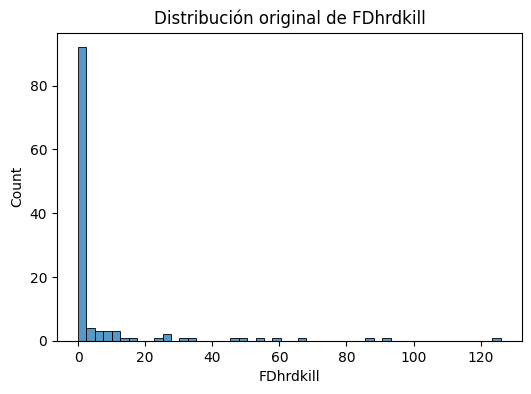

🔍 RMSE: 16.76
🔍 R²: 0.680


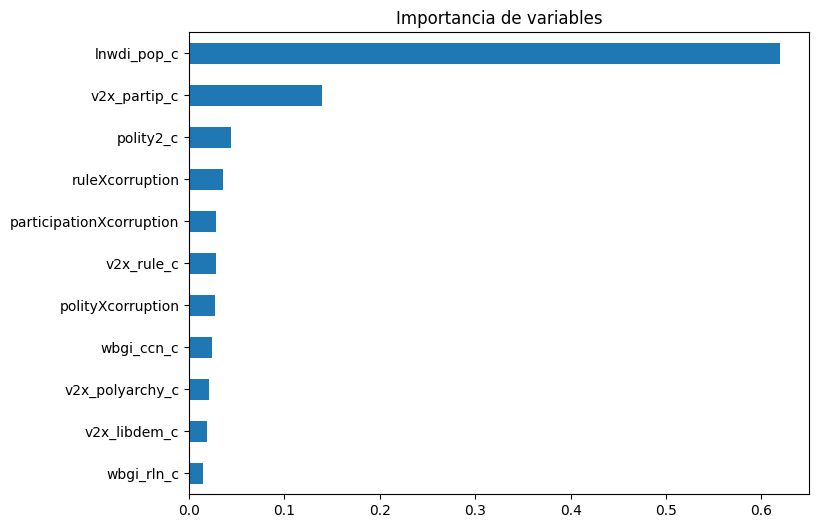

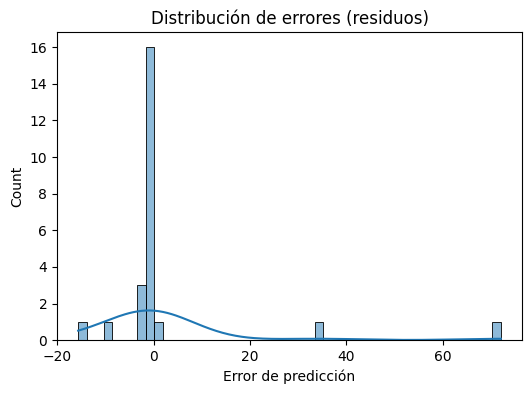

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

# 1. Selección de variables
# vars_reducidas = [v for v in vars_modelo if v != "lnwdi_pop"]

X = df_vdem_latam[columns_centered_final].copy()
y = df_vdem_latam["FDhrdkill"]

X = X.replace([np.inf, -np.inf], np.nan)
y = y.replace([np.inf, -np.inf], np.nan)

# Eliminar filas con NaN
df_rf = pd.concat([X, y], axis=1).dropna()
X = df_rf[columns_centered_final]
y = df_rf["FDhrdkill"]

# Distribución original
plt.figure(figsize=(6,4))
sns.histplot(y, bins=50, kde=False)
plt.title("Distribución original de FDhrdkill")
plt.show()

# Log-transformación
y_log = np.log1p(y)

# División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Modelo Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predicciones
y_pred_log = rf.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

# Evaluación
rmse = sqrt(mean_squared_error(y_test_real, y_pred))
r2 = r2_score(y_test_real, y_pred)

print(f"🔍 RMSE: {rmse:.2f}")
print(f"🔍 R²: {r2:.3f}")

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(8,6), title="Importancia de variables")
plt.show()

residuals = y_test_real - y_pred
plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Distribución de errores (residuos)")
plt.xlabel("Error de predicción")
plt.show()


##Esctructura


In [ ]:
# df.groupby("countrycode").size().describe()


,0
count,195.000000
mean,64.789744
std,24.992409
min,63.000000
25%,63.000000
50%,63.000000
75%,63.000000
max,412.000000


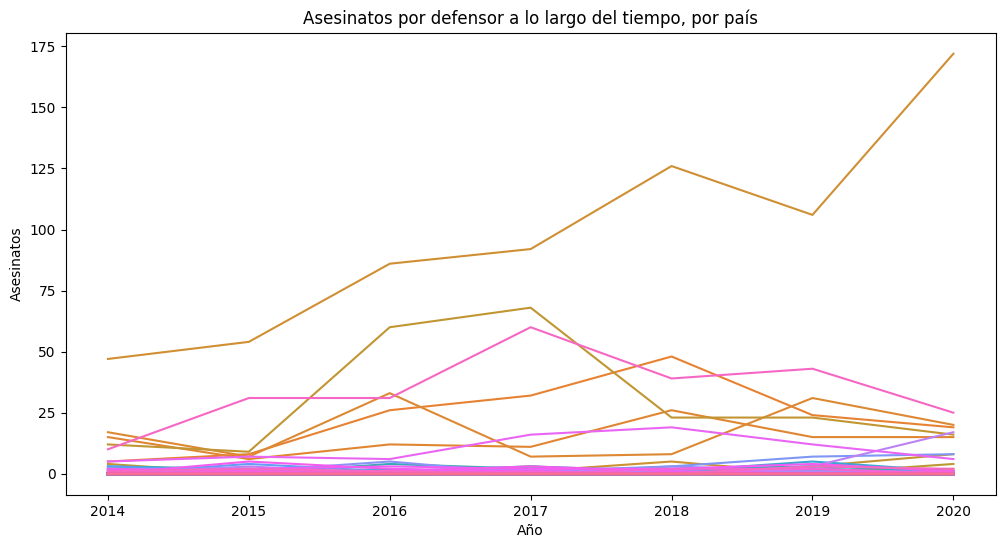

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_vdem, x="year", y="FDhrdkill", hue="countrycode", legend=False)
plt.title("Asesinatos por defensor a lo largo del tiempo, por país")
plt.xlabel("Año")
plt.ylabel("Asesinatos")
plt.xticks(sorted(df_vdem["year"].dropna().unique()))  # Fuerza los ticks del eje X
plt.show()


In [ ]:
# print(sorted(df_vdem["year"].dropna().unique()))


[np.int64(2000), np.int64(2001), np.int64(2002)]


In [ ]:
# for pais in df_vdem["countrycode"].unique():
#     serie = df_vdem[df_vdem["countrycode"] == pais]["FDhrdkill"]
#     if len(serie) > 1:
#         autocorr = serie.autocorr(lag=1)
#         print(f"{pais}: autocorrelación = {autocorr:.2f}")


/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


USA: autocorrelación = nan
nan: autocorrelación = nan
CAN: autocorrelación = nan
BHS: autocorrelación = nan
CUB: autocorrelación = nan
HTI: autocorrelación = -0.32
DOM: autocorrelación = -0.20
JAM: autocorrelación = nan
TTO: autocorrelación = nan
BRB: autocorrelación = nan
DMA: autocorrelación = nan
GRD: autocorrelación = nan
LCA: autocorrelación = nan
VCT: autocorrelación = nan
ATG: autocorrelación = nan
KNA: autocorrelación = nan
MEX: autocorrelación = 0.45
BLZ: autocorrelación = -0.20
GTM: autocorrelación = -0.04
HND: autocorrelación = -0.43
SLV: autocorrelación = -0.33
NIC: autocorrelación = -0.66
CRI: autocorrelación = 0.63
PAN: autocorrelación = nan
COL: autocorrelación = 0.68
VEN: autocorrelación = -0.12
GUY: autocorrelación = nan
SUR: autocorrelación = nan
ECU: autocorrelación = 0.14
PER: autocorrelación = 0.30
BRA: autocorrelación = 0.23
BOL: autocorrelación = 0.63
PRY: autocorrelación = nan
CHL: autocorrelación = nan
ARG: autocorrelación = 0.25
URY: autocorrelación = nan
GBR:

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import NegativeBinomial
from statsmodels.genmod.cov_struct import Independence, Exchangeable, Autoregressive

# 1. Construir el DataFrame limpio
df_model = pd.concat([X, y, df_vdem[["year", "countrycode"]]], axis=1).dropna()

X_clean = df_model[X.columns]
y_clean = df_model["FDhrdkill"]
groups  = df_model["countrycode"]
time    = df_model["year"].values.ravel()  # importante: plano

# 2. Estimar alpha
glm_nb = sm.GLM(y_clean, sm.add_constant(X_clean), family=NegativeBinomial()).fit()
alpha_hat = glm_nb.scale
print(f"Alpha estimado: {alpha_hat:.4f}")

# 3. Ajustar modelos GEE
gee_indep = GEE(y_clean, X_clean, groups=groups,
                family=NegativeBinomial(alpha=alpha_hat),
                cov_struct=Independence()).fit()

gee_exch = GEE(y_clean, X_clean, groups=groups,
               family=NegativeBinomial(alpha=alpha_hat),
               cov_struct=Exchangeable()).fit()

# gee_ar = GEE(y_clean, X_clean, groups=groups, time=time,
#              family=NegativeBinomial(alpha=alpha_hat),
#              cov_struct=Autoregressive()).fit()


/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)

✅ Alpha estimado: 1.0000


In [ ]:
comparison = pd.DataFrame({
    "Coef_Indep": gee_indep.params,
    "SE_Indep":   gee_indep.bse,
    "Coef_Exch":  gee_exch.params,
    "SE_Exch":    gee_exch.bse,
    # "Coef_AR":    gee_ar.params,
    # "SE_AR":      gee_ar.bse
})
print("\n Comparación de errores estándar:")
print(comparison)



📊 Comparación de errores estándar:
                Coef_Indep  SE_Indep  Coef_Exch   SE_Exch
lngdp1000         0.282087  0.010136   0.246507  0.001600
asinhfdi          3.497848  0.010184   3.531422  0.005311
lnmineralrents    2.314646  0.066619   2.533762  0.014048
lnforestrents     2.225762  0.016176   2.433466  0.002781
polity2_10        3.851628  0.007122   3.916943  0.001691
...                    ...       ...        ...       ...
v2clkill         -4.927733  0.026593  -5.029173  0.000549
v2cltort         -5.612937  0.010900  -5.652866  0.001771
v2clacjstm       -0.098512  0.002789  -0.115203  0.000858
v2exrescon        2.288626  0.009868   2.376905  0.000668
v2regimpgroup    -3.415842  0.007183  -3.419781  0.003779

[74 rows x 4 columns]


In [ ]:
def compute_qic(result):
    mu = result.fittedvalues
    y = result.model.endog
    scale = result.scale
    # Quasi-likelihood para Negative Binomial
    ql = np.sum(y * np.log(mu / (mu + scale)) - (y + scale) * np.log(1 + mu / scale))

    # Penalización por complejidad: tr(V̂)
    penalty = np.trace(result.cov_params())

    return -2 * ql + 2 * penalty


qic_indep = compute_qic(gee_indep)
qic_exch  = compute_qic(gee_exch)

print("\n QIC para cada estructura:")
print(f"Independence:   {qic_indep:.2f}")
print(f"Exchangeable:   {qic_exch:.2f}")



📉 QIC para cada estructura:
Independence:   24.34
Exchangeable:   24.29


In [ ]:
# Calcular p-values
pvals_indep = gee_indep.pvalues
pvals_exch = gee_exch.pvalues

# Contar significativos
sig_indep = (pvals_indep < 0.05).sum()
sig_exch  = (pvals_exch < 0.05).sum()

print(f"\n Coeficientes significativos (p < 0.05):")
print(f"Independence:   {sig_indep} de {len(pvals_indep)}")
print(f"Exchangeable:   {sig_exch} de {len(pvals_exch)}")



🔍 Coeficientes significativos (p < 0.05):
Independence:   66 de 74
Exchangeable:   69 de 74


#FIN

#prueba 2

##3dddd


In [ ]:
import difflib

def find_similar_columns(target, df, n=5, cutoff=0.6):
    """
    Find column names in df that are similar to target.

    Parameters:
        target (str): The column name you're looking for.
        df (DataFrame): The DataFrame where to search.
        n (int): Max number of suggestions.
        cutoff (float): Similarity threshold (0 to 1).

    Returns:
        List of similar column names.
    """
    return difflib.get_close_matches(target, df.columns, n=n, cutoff=cutoff)


In [ ]:
# Suppose you mistyped 'v2clkill'
find_similar_columns('v2smgovsmcenprc', df_vdem)


[]

In [ ]:
import difflib

# Variables que quieres encontrar
nuevas_vars = [
    'v2svinlaut', 'v2smgovsmcenprc', 'v2smorgavgact',
    'v2clslavem', 'v2clslavef', 'v2lgdomchm',
    'v2pscomprg', 'v3cllabrig'
]

# Buscar columnas similares
for var in nuevas_vars:
    similares = difflib.get_close_matches(var, df_merged_com.columns, n=3, cutoff=0.4)
    print(f" '{var}' → Similares: {similares}")


🔍 'v2svinlaut' → Similares: ['v2cscnsult', 'v2x_hosinter', 'v2cscnsult_sd']
🔍 'v2smgovsmcenprc' → Similares: ['v2x_genpp', 'v2x_gencs', 'v2x_gencl']
🔍 'v2smorgavgact' → Similares: ['v2x_horacc', 'v2cseeorgs', 'v2x_diagacc']
🔍 'v2clslavem' → Similares: ['v2xcl_slave', 'v2xcl_slave_sd', 'ccp_slave']
🔍 'v2clslavef' → Similares: ['v2xcl_slave', 'v2xcl_slave_sd', 'ccp_slave']
🔍 'v2lgdomchm' → Similares: ['v2xdd_toc', 'wdi_empchm', 'v2x_libdem']
🔍 'v2pscomprg' → Similares: ['v2jucomp', 'v2cseeorgs', 'polcomp']
🔍 'v3cllabrig' → Similares: ['v2x_clpriv', 'v2xcl_slave', 'killing']


#bueno

In [ ]:
# Paso 1: Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:

import pandas as pd

 Cargar los archivos CSV
ruta_america = "/content/drive/My Drive/Verano25/GOETHE/Proyecto/Datos/AMERICA.csv"
ruta_todos = "/content/drive/My Drive/Verano25/GOETHE/Proyecto/Datos/Todos.csv"

df_merged_com = pd.read_csv(ruta_todos)




# # Paso 4 (opcional): Mostrar las primeras filas de cada DataFrame
# print("Primeras filas de AMERICA.csv:")
# print(df_merged_latam.head())

print("\nPrimeras filas de Todos.csv:")
print(df_merged_com.head())


Primeras filas de Todos.csv:
  countrycode    countryname region     regionname adminregion  \
0         USA  United States    NAC  North America         NaN   
1         USA  United States    NAC  North America         NaN   
2         USA  United States    NAC  North America         NaN   
3         USA  United States    NAC  North America         NaN   
4         USA  United States    NAC  North America         NaN   

  adminregionname incomelevel incomelevelname lendingtype lendingtypename  \
0             NaN         HIC     High income         LNX  Not classified   
1             NaN         HIC     High income         LNX  Not classified   
2             NaN         HIC     High income         LNX  Not classified   
3             NaN         HIC     High income         LNX  Not classified   
4             NaN         HIC     High income         LNX  Not classified   

   ...  dyear9  dyear10  dyear11  dyear12  dyear13 dyear14  dyear15  dyear16  \
0  ...     0.0      0.0      0

/tmp/ipython-input-7-1335528385.py:9: DtypeWarning: Columns (382,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406) have mixed types. Specify dtype option on import or set low_memory=False.
  df_merged_com = pd.read_csv(ruta_todos)


In [ ]:
# df_merged_com.columns.tolist()

In [ ]:
# df_merged_com.columns.tolist()

In [ ]:
import numpy as np
import pandas as pd

# Variables de derechos humanos y controles
control_vars = [
    "v2clkill", "v2cltort",
    "v2xcl_slave",
    "v2x_clpriv",
    "v2cseeorgs",
    "v2jucomp"
]

# Variables económicas (nuevas + antiguas)
economic_vars = [
    'asinhfdi', 'lnmineralrents', 'lnforestrents',
    'wdi_export', 'wdi_trade'
]

# Variables políticas
political_vars = ['polity2_10', 'lnallprotest']

# Institucionales
institutional_vars = ['corruption', 'RuleofLaw', 'v2x_freexp_altinf_extra', 'v2xel_frefair']

# Conflicto
conflict_vars = ['armedconflict', 'homicides_ipo']

# Demográficas
demographic_vars = ['lnIndigenous']

# Variables de mercado y energía
market_energy_vars = ['ccp_market', 'wdi_elerenew']

# Dummies
dummies = [
    'underreporting', 'MENA', 'Asia', 'SSAfrica', 'Americas', 'Western',
    'dyear1', 'dyear2', 'dyear3', 'dyear4', 'dyear5', 'dyear6',
    'dyear7', 'dyear8', 'dyear9', 'dyear10', 'dyear11', 'dyear12',
    'dyear13', 'dyear14', 'dyear15', 'dyear16', 'dyear17', 'dyear18'
]

# Combinar todas
all_predictors = (
    economic_vars +
    political_vars +
    institutional_vars +
    conflict_vars +
    demographic_vars +
    market_energy_vars +
    control_vars
)

# Centrar numéricas
columns_to_keep = all_predictors
vars_a_centrar = [
    col for col in columns_to_keep
    if col not in dummies and df_merged_com[col].dtype in [np.float64, np.int64]
]

for col in vars_a_centrar:
    df_merged_com[col + '_c'] = df_merged_com[col] - df_merged_com[col].mean()

# Nuevas interacciones LATAM
interactions = {
    'mineralXcorruption':        ('lnmineralrents_c', 'corruption_c'),
    'indigenousXmineral':        ('lnIndigenous_c', 'lnmineralrents_c'),
    'fdiXruleoflaw':             ('asinhfdi_c', 'RuleofLaw_c'),
    'protestXcorruption':        ('lnallprotest_c', 'corruption_c'),
    'jucompXindigenous':         ('v2jucomp_c', 'lnIndigenous_c'),
    'polityXcorruption':         ('polity2_10_c', 'corruption_c'),
    'v2clkillXcorruption':       ('v2clkill_c', 'corruption_c'),
    'tradeXrenewables':          ('wdi_trade_c', 'wdi_elerenew_c'),
    'exportXccpmarket':          ('wdi_export_c', 'ccp_market_c'),
    'freeexpXruleoflaw':         ('v2x_freexp_altinf_extra_c', 'RuleofLaw_c')
}

# Crear interacciones
interaction_vars = []
for name, (var1, var2) in interactions.items():
    if var1 in df_merged_com.columns and var2 in df_merged_com.columns:
        df_merged_com[name] = df_merged_com[var1] * df_merged_com[var2]
        interaction_vars.append(name)
    else:
        print(f" No se pudo crear {name} porque falta '{var1}' o '{var2}'.")

# Lista final
columns_centered_final = []
for col in columns_to_keep:
    if col in vars_a_centrar:
        columns_centered_final.append(col + "_c")
    elif col in dummies:
        columns_centered_final.append(col)

columns_centered_final += interaction_vars

# Lista final lista para modelar
# df_com_selected = df_merged_com[columns_centered_final].copy()


In [ ]:
# import pandas as pd

# pd.Series(columns_centered_final).str.contains('wdi').count()


np.int64(74)

In [ ]:
# Filtrar por años y países de LATAM
df_merged_latam = df_merged_com[
    (df_merged_com["year"].between(2014, 2020)) &
    (df_merged_com["regionname"] == 'Latin America and Caribbean')
]


df_com_selected = df_merged_com[df_merged_com["year"].between(2014, 2020)]



In [ ]:
# df_merged_latam.columns.tolist()

#Modelo latam

##Checar VIF

In [ ]:
print(columns_centered_final)



['lnhrcountfilled_c', 'lnwdi_pop_c', 'lnwdi_gdpcapcon2010_c', 'lnAidAllNGOs_c', 'lnAidHumanRights_c', 'PTS_S_c', 'totalprotest_c', 'locationconflict_c', 'v2juhcind_c', 'v2clrspct_c', 'v2exbribe_c', 'v2jucomp_c', 'v2mecrit_c', 'v2mecenefm_c', 'v2cacamps_c', 'v2clkill_c', 'v2cltort_c', 'v2clacjstm_c', 'v2exrescon_c', 'v2regimpgroup_c', 'lngdp1000_c', 'asinhfdi_c', 'lnmineralrents_c', 'lnforestrents_c', 'polity2_10_c', 'sqpolity2_10_c', 'lnallprotest_c', 'corruption_c', 'armedconflict_c', 'lnhomicides_ipo_c', 'lnpopulation_c', 'Popdensity_c', 'Ruralpopulation_c', 'youngmale_c', 'lnIndigenous_c', 'underreporting', 'MENA', 'Asia', 'SSAfrica', 'Americas', 'Western', 'dyear1', 'dyear2', 'dyear3', 'dyear4', 'dyear5', 'dyear6', 'dyear7', 'dyear8', 'dyear9', 'dyear10', 'dyear11', 'dyear12', 'dyear13', 'dyear14', 'dyear15', 'dyear16', 'dyear17', 'dyear18', 'mineralXcorruption', 'protestXpolity', 'fdiXruleoflaw', 'indigenousXmineral', 'polityXcorruption', 'protestXhomicide', 'indigenousXruleoflaw'

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


df = df_merged_latam.copy()

X_vif = df[columns_centered_final].copy()

X_vif = X_vif.replace([np.inf, -np.inf], np.nan)
X_vif = X_vif.fillna(X_vif.mean())
X_vif = X_vif.loc[:, X_vif.std() > 0]

X_vif = sm.add_constant(X_vif)

vif_df = pd.DataFrame()
vif_df["variable"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("VIF de las variables seleccionadas:")
print(vif_df)

###



✅ VIF de las variables seleccionadas:
                     variable        VIF
0                       const  56.128922
1                  asinhfdi_c   1.851661
2            lnmineralrents_c   6.445482
3             lnforestrents_c   2.623694
4                wdi_export_c  27.594810
5                 wdi_trade_c  29.129559
6                polity2_10_c  14.479576
7              lnallprotest_c   2.268967
8                corruption_c  33.340853
9                 RuleofLaw_c  24.253953
10  v2x_freexp_altinf_extra_c  54.406319
11            v2xel_frefair_c  19.565453
12            armedconflict_c   1.827223
13            homicides_ipo_c   3.173539
14             lnIndigenous_c   4.980673
15               ccp_market_c  31.135254
16             wdi_elerenew_c   2.055326
17                 v2clkill_c   7.113698
18                 v2cltort_c   5.083570
19              v2xcl_slave_c   4.698159
20               v2x_clpriv_c  17.404247
21               v2cseeorgs_c  17.527132
22                 

In [ ]:
# pd.Series(vif_df['variable'].tolist()).str.contains('wdi_')
# #

In [ ]:
# 'wdi_empindf_c' in vif_df.columns.tolist()

False

In [ ]:
# Detectar variables con VIF > 10
vars_vif_alto = vif_df[vif_df["VIF"] > 10]["variable"].tolist()

# Verificar que realmente estén en el DataFrame
vars_vif_alto_en_X = [var for var in vars_vif_alto if var in X_vif.columns]

# Eliminar variables con VIF alto (nuevo nombre para X)
X_vif_reducido = X_vif.drop(columns=vars_vif_alto_en_X)

# Mostrar resumen
print(f"\nSe eliminaron {len(vars_vif_alto_en_X)} variables por VIF > 10:")
print(vars_vif_alto_en_X)

print(f"\nVariables restantes: {len(X_vif_reducido.columns)}")
print("Variables con VIF aceptable:")
print(X_vif_reducido.columns.tolist())


🔴 Se eliminaron 15 variables por VIF > 10:
['const', 'wdi_export_c', 'wdi_trade_c', 'polity2_10_c', 'corruption_c', 'RuleofLaw_c', 'v2x_freexp_altinf_extra_c', 'v2xel_frefair_c', 'ccp_market_c', 'v2x_clpriv_c', 'v2cseeorgs_c', 'v2jucomp_c', 'polityXcorruption', 'exportXccpmarket', 'freeexpXruleoflaw']

✅ Variables restantes: 18
📋 Variables con VIF aceptable:
['asinhfdi_c', 'lnmineralrents_c', 'lnforestrents_c', 'lnallprotest_c', 'armedconflict_c', 'homicides_ipo_c', 'lnIndigenous_c', 'wdi_elerenew_c', 'v2clkill_c', 'v2cltort_c', 'v2xcl_slave_c', 'mineralXcorruption', 'indigenousXmineral', 'fdiXruleoflaw', 'protestXcorruption', 'jucompXindigenous', 'v2clkillXcorruption', 'tradeXrenewables']


In [ ]:
# 'wdi_empindf_c' in X_vif_reducido

False

In [ ]:
print("🧹 Variables con VIF aceptable:")
print(X_vif_reducido.columns.tolist())


🧹 Variables con VIF aceptable:
['const', 'lnwdi_gdpcapcon2010_c', 'PTS_S_c', 'totalprotest_c', 'v2cacamps_c', 'v2regimpgroup_c', 'asinhfdi_c', 'lnmineralrents_c', 'lnforestrents_c', 'lnallprotest_c', 'lnhomicides_ipo_c', 'lnIndigenous_c', 'mineralXcorruption', 'protestXpolity', 'fdiXruleoflaw', 'indigenousXmineral', 'protestXhomicide', 'forestXcorruption', 'protestXmineral', 'fdiXindigenous', 'gdpindXmineral', 'empindXprotests', 'empindXindigenous']


#Comporacion

In [ ]:

# Suponiendo que tienes:
# interactions: dict con interacciones {nombre: (var1, var2)}
# X_vif_reducido: DataFrame con columnas validadas (con VIF bajo)
# interaction_vars: lista con todos los nombres de interacciones posibles (opcional)

# 1. Filtrar interacciones válidas
interacciones_validas = {
    nombre: (var1, var2)
    for nombre, (var1, var2) in interactions.items()
    if var1 in X_vif_reducido.columns and var2 in X_vif_reducido.columns
}

print(f"Interacciones válidas ({len(interacciones_validas)}):")
print(list(interacciones_validas.keys()))

# 2. Extraer variables base de las interacciones válidas
vars_base = set()
for var1, var2 in interacciones_validas.values():
    vars_base.add(var1)
    vars_base.add(var2)
vars_base = list(vars_base)

# 3. Identificar otras variables en X_vif_reducido que no son bases ni interacciones ni 'const'
otras_vars = [
    var for var in X_vif_reducido.columns
    if var not in vars_base and var not in interacciones_validas.keys() and var != 'const'
    and var not in interaction_vars
]


# 4. Crear lista final de variables para el modelo
variables_modelo = vars_base + list(interacciones_validas.keys()) + otras_vars

print(f"Total variables para modelo: {len(variables_modelo)}")
print(variables_modelo)

# Ahora puedes usar variables_modelo para seleccionar columnas en tu DataFrame:
# X_modelo = df_merged_com[variables_modelo].copy()


Interacciones válidas (1):
['indigenousXmineral']
Total variables para modelo: 12
['lnIndigenous_c', 'lnmineralrents_c', 'indigenousXmineral', 'asinhfdi_c', 'lnforestrents_c', 'lnallprotest_c', 'armedconflict_c', 'homicides_ipo_c', 'wdi_elerenew_c', 'v2clkill_c', 'v2cltort_c', 'v2xcl_slave_c']


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import NegativeBinomial
from statsmodels.genmod.cov_struct import Exchangeable, Independence

# 1. Copiar base
df = df_merged_latam.copy()
df["countrycode"] = df["countrycode"].astype(str)
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

# 2. Validar que las variables de variables_modelo existan en df y tengan ≥ 60% datos válidos
threshold = 0.6
valid_vars = [
    var for var in variables_modelo
    if var != "const" and var in df.columns and df[var].notnull().mean() >= threshold
]

# valid_vars = variables_modelo
# 3. Construir X y agregar constante
X = df[valid_vars].copy()
X = sm.add_constant(X)

# 4. Reemplazar inf y NaN
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X = X.fillna(X.mean())

# 5. Variable dependiente
y = df["FDhrdkill"].replace([np.inf, -np.inf], np.nan).fillna(df["FDhrdkill"].mean())

# 6. Filtrar observaciones completas
mask = X.notnull().all(axis=1) & y.notnull()
X = X[mask]
y = y[mask]
groups = df.loc[mask, "countrycode"].astype(str).to_numpy().ravel()
time = df.loc[mask, "year"].to_numpy().ravel()

# 7. Verificación
print("Observaciones finales:", len(y))
print(" Variables incluidas:", X.columns.tolist())

# 8. Modelos GEE

print("\n Intento 2: GEE + NegativeBinomial + Independence")
model_latam_2_com = GEE(y, X, groups=groups, time=time, cov_struct=Independence(), family=NegativeBinomial())
result2_latam_com = model_latam_2_com.fit()
print(result2_latam_com.summary())

print("\n Intento 3: GEE + NegativeBinomial + Exchangeable")
model_latam_3_com = GEE(y, X, groups=groups, time=time, cov_struct=Exchangeable(), family=NegativeBinomial())
result3_latam_com = model_latam_3_com.fit()
print(result3_latam_com.summary())


📌 Observaciones finales: 165
📌 Variables incluidas: ['const', 'lnIndigenous_c', 'lnmineralrents_c', 'indigenousXmineral', 'asinhfdi_c', 'lnforestrents_c', 'lnallprotest_c', 'armedconflict_c', 'homicides_ipo_c', 'wdi_elerenew_c', 'v2clkill_c', 'v2cltort_c', 'v2xcl_slave_c']

🔹 Intento 2: GEE + NegativeBinomial + Independence
                               GEE Regression Results                              
Dep. Variable:                   FDhrdkill   No. Observations:                  165
Model:                                 GEE   No. clusters:                       33
Method:                        Generalized   Min. cluster size:                   5
                      Estimating Equations   Max. cluster size:                   5
Family:                   NegativeBinomial   Mean cluster size:                 5.0
Dependence structure:         Independence   Num. iterations:                    29
Date:                     Fri, 04 Jul 2025   Scale:                           1.000
Co

/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                               GEE Regression Results                              
Dep. Variable:                   FDhrdkill   No. Observations:                  165
Model:                                 GEE   No. clusters:                       33
Method:                        Generalized   Min. cluster size:                   5
                      Estimating Equations   Max. cluster size:                   5
Family:                   NegativeBinomial   Mean cluster size:                 5.0
Dependence structure:         Exchangeable   Num. iterations:                    60
Date:                     Fri, 04 Jul 2025   Scale:                           1.000
Covariance type:                    robust   Time:                         12:35:04
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -2.5522      0.862     -2.961      0.003      -4

/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/generalized_estimating_equations.py:1300: IterationLimitWarning: Iteration limit reached prior to convergence
  warnings.warn("Iteration limit reached prior to convergence",


In [ ]:

summary_df_latam_com = result2_latam_com.summary2().tables[1]

# Filtrar variables significativas (p < 0.05)
significativas_com = summary_df_latam_com[summary_df_latam_com["P>|z|"] < 0.05]

# Obtener solo los nombres de las variables
lista_significativas = significativas_com.index.tolist()

# Mostrar
print("Variables significativas (p < 0.05):")
print(lista_significativas)

###
summary_df_latam_2_com = result3_latam_com.summary2().tables[1]

# Filtrar variables significativas (p < 0.05)
significativas_2_com = summary_df_latam_2_com[summary_df_latam_2_com["P>|z|"] < 0.05]

# Obtener solo los nombres de las variables
lista_significativas_2 = significativas_2_com.index.tolist()

# Mostrar
print("Variables significativas (p < 0.05):")
print(lista_significativas_2)

###


📌 Variables significativas (p < 0.05):
['const', 'lnIndigenous_c', 'asinhfdi_c', 'lnforestrents_c', 'homicides_ipo_c', 'v2clkill_c', 'v2xcl_slave_c']
📌 Variables significativas (p < 0.05):
['const', 'lnIndigenous_c', 'asinhfdi_c', 'lnforestrents_c', 'homicides_ipo_c', 'v2clkill_c', 'v2xcl_slave_c']


In [ ]:
# df_merged_latam[df_merged_latam["countryname"] == "Mexico"][["FDhrdkill", "countryname"]]


,FDhrdkill,countryname
284,5.0,Mexico
285,8.0,Mexico
286,26.0,Mexico
287,32.0,Mexico
288,48.0,Mexico


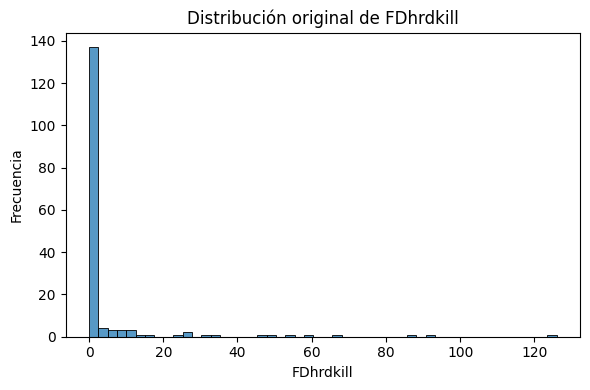

🔍 RMSE: 4.58
🔍 R²: 0.759


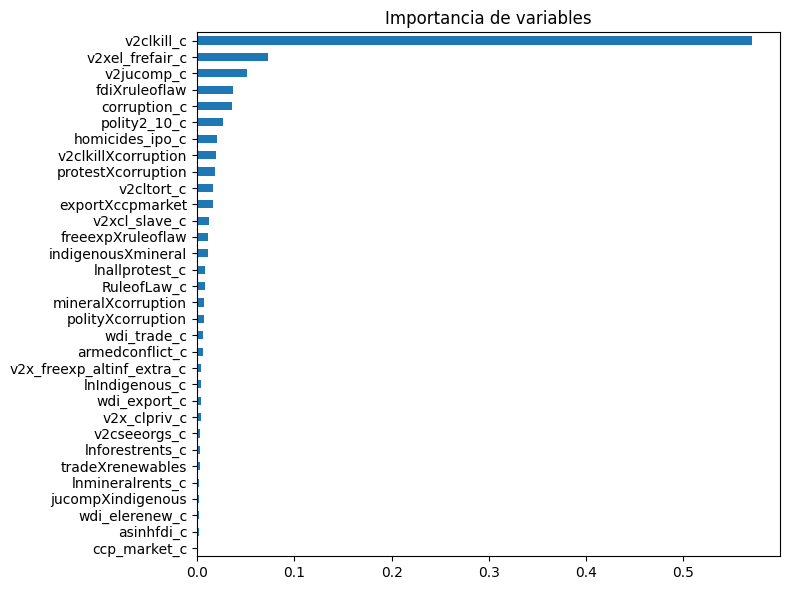

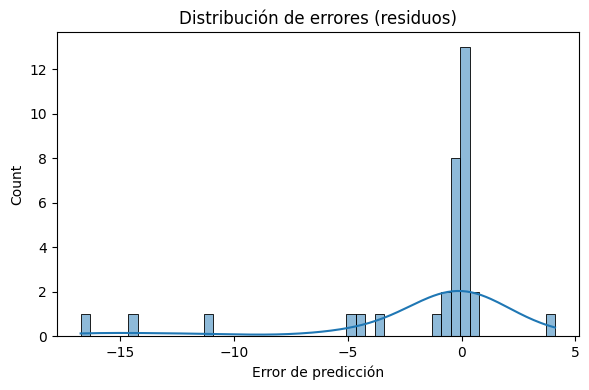

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

# 🔹 1. Definir tus variables predictoras
# Asegúrate de tener esta lista definida
# Ejemplo:
# columns_centered_final = ["v2x_partip_c", "v2x_rule_c", "polity2_c", "RuleofLaw", "corruption", "mineralrents", ...]

X = df_merged_latam[columns_centered_final].copy()
y = df_merged_latam["FDhrdkill"]


X = X.replace([np.inf, -np.inf], np.nan)
y = y.replace([np.inf, -np.inf], np.nan)


X = X.fillna(X.mean())
y = y.fillna(y.mean())


plt.figure(figsize=(6, 4))
sns.histplot(y, bins=50, kde=False)
plt.title("Distribución original de FDhrdkill")
plt.xlabel("FDhrdkill")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


y_log = np.log1p(y)  # log(1 + y)


X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)


rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)


y_pred_log = rf.predict(X_test)


y_pred = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)


rmse = sqrt(mean_squared_error(y_test_real, y_pred))
r2 = r2_score(y_test_real, y_pred)

print(f"🔍 RMSE: {rmse:.2f}")
print(f"🔍 R²: {r2:.3f}")

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(8, 6), title="Importancia de variables")
plt.tight_layout()
plt.show()

residuals = y_test_real - y_pred
plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Distribución de errores (residuos)")
plt.xlabel("Error de predicción")
plt.tight_layout()
plt.show()


#Normal

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


df = df_com_selected.copy()


X_vif = df[columns_centered_final].copy()


X_vif = X_vif.replace([np.inf, -np.inf], np.nan)
X_vif = X_vif.fillna(X_vif.mean())  # imputar con la media


X_vif = X_vif.loc[:, X_vif.std() > 0]


X_vif = sm.add_constant(X_vif)

#  Calcular VIF
vif_df = pd.DataFrame()
vif_df["variable"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("VIF de las variables seleccionadas:")
print(vif_df)

###



✅ VIF de las variables seleccionadas:
               variable        VIF
0                 const   2.513139
1            asinhfdi_c   1.269410
2      lnmineralrents_c   1.410440
3       lnforestrents_c   1.504996
4          polity2_10_c   3.417209
5        lnallprotest_c   1.139412
6          corruption_c  15.069173
7           RuleofLaw_c  15.419652
8       armedconflict_c   1.417911
9       homicides_ipo_c   1.251235
10       lnIndigenous_c   1.430460
11           v2clkill_c   5.735084
12           v2cltort_c   6.767095
13        v2xcl_slave_c   3.360860
14         v2x_clpriv_c   7.496936
15         v2cseeorgs_c   4.150033
16           v2jucomp_c   3.434202
17   mineralXcorruption   1.205505
18   indigenousXmineral   1.262801
19        fdiXruleoflaw   1.309341
20   protestXcorruption   1.166613
21    jucompXindigenous   1.245429
22    polityXcorruption   2.155067
23  v2clkillXcorruption   2.497821


#general

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

df = df_com_selected.copy()

X_vif = df[columns_centered_final].copy()  # o usa vars_modelo si ese es tu nombre

X_vif = X_vif.replace([np.inf, -np.inf], np.nan)
X_vif = X_vif.fillna(X_vif.mean())  # imputar con la media

X_vif = X_vif.loc[:, X_vif.std() > 0]

X_vif = sm.add_constant(X_vif)

# Calcular VIF
vif_df = pd.DataFrame()
vif_df["variable"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

#Mostrar resultados
print("VIF de las variables seleccionadas:")
print(vif_df)

###



✅ VIF de las variables seleccionadas:
                     variable        VIF
0                       const   2.952484
1                  asinhfdi_c   1.435527
2            lnmineralrents_c   1.459161
3             lnforestrents_c   1.646467
4                wdi_export_c  16.836868
5                 wdi_trade_c  16.075969
6                polity2_10_c   5.381522
7              lnallprotest_c   1.166872
8                corruption_c  15.887115
9                 RuleofLaw_c  16.726086
10  v2x_freexp_altinf_extra_c   8.335384
11            v2xel_frefair_c   5.092756
12            armedconflict_c   1.585467
13            homicides_ipo_c   1.265791
14             lnIndigenous_c   1.514692
15               ccp_market_c   1.167891
16             wdi_elerenew_c   1.165623
17                 v2clkill_c   6.304762
18                 v2cltort_c   7.677551
19              v2xcl_slave_c   3.454298
20               v2x_clpriv_c   8.627133
21               v2cseeorgs_c   5.262791
22                 

In [ ]:
vars_vif_alto = vif_df[vif_df["VIF"] > 10]["variable"].tolist()

vars_vif_alto_en_X = [var for var in vars_vif_alto if var in X_vif.columns]

# Eliminar variables con VIF alto (nuevo nombre para X)
X_vif_reducido = X_vif.drop(columns=vars_vif_alto_en_X)

print(f"\n Se eliminaron {len(vars_vif_alto_en_X)} variables por VIF > 10:")
print(vars_vif_alto_en_X)

print(f"\n Variables restantes: {len(X_vif_reducido.columns)}")
print("Variables con VIF aceptable:")
print(X_vif_reducido.columns.tolist())


🔴 Se eliminaron 4 variables por VIF > 10:
['wdi_export_c', 'wdi_trade_c', 'corruption_c', 'RuleofLaw_c']

✅ Variables restantes: 29
📋 Variables con VIF aceptable:
['const', 'asinhfdi_c', 'lnmineralrents_c', 'lnforestrents_c', 'polity2_10_c', 'lnallprotest_c', 'v2x_freexp_altinf_extra_c', 'v2xel_frefair_c', 'armedconflict_c', 'homicides_ipo_c', 'lnIndigenous_c', 'ccp_market_c', 'wdi_elerenew_c', 'v2clkill_c', 'v2cltort_c', 'v2xcl_slave_c', 'v2x_clpriv_c', 'v2cseeorgs_c', 'v2jucomp_c', 'mineralXcorruption', 'indigenousXmineral', 'fdiXruleoflaw', 'protestXcorruption', 'jucompXindigenous', 'polityXcorruption', 'v2clkillXcorruption', 'tradeXrenewables', 'exportXccpmarket', 'freeexpXruleoflaw']


In [ ]:

# Suponiendo que tienes:
# interactions: dict con interacciones {nombre: (var1, var2)}
# X_vif_reducido: DataFrame con columnas validadas (con VIF bajo)
# interaction_vars: lista con todos los nombres de interacciones posibles (opcional)

interacciones_validas = {
    nombre: (var1, var2)
    for nombre, (var1, var2) in interactions.items()
    if var1 in X_vif_reducido.columns and var2 in X_vif_reducido.columns
}

print(f"Interacciones válidas ({len(interacciones_validas)}):")
print(list(interacciones_validas.keys()))

vars_base = set()
for var1, var2 in interacciones_validas.values():
    vars_base.add(var1)
    vars_base.add(var2)
vars_base = list(vars_base)

otras_vars = [
    var for var in X_vif_reducido.columns
    if var not in vars_base and var not in interacciones_validas.keys() and var != 'const'
    and var not in interaction_vars
]


# 4. Crear lista final de variables para el modelo
variables_modelo = vars_base + list(interacciones_validas.keys()) + otras_vars

print(f"Total variables para modelo: {len(variables_modelo)}")
print(variables_modelo)

# Ahora puedes usar variables_modelo para seleccionar columnas en tu DataFrame:
# X_modelo = df_merged_com[variables_modelo].copy()


Interacciones válidas (2):
['indigenousXmineral', 'jucompXindigenous']
Total variables para modelo: 20
['lnIndigenous_c', 'lnmineralrents_c', 'v2jucomp_c', 'indigenousXmineral', 'jucompXindigenous', 'asinhfdi_c', 'lnforestrents_c', 'polity2_10_c', 'lnallprotest_c', 'v2x_freexp_altinf_extra_c', 'v2xel_frefair_c', 'armedconflict_c', 'homicides_ipo_c', 'ccp_market_c', 'wdi_elerenew_c', 'v2clkill_c', 'v2cltort_c', 'v2xcl_slave_c', 'v2x_clpriv_c', 'v2cseeorgs_c']


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import NegativeBinomial
from statsmodels.genmod.cov_struct import Exchangeable, Independence

df = df_com_selected.copy()
df["countrycode"] = df["countrycode"].astype(str)
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

threshold = 0.6
valid_vars = [
    var for var in variables_modelo
    if var != "const" and var in df.columns and df[var].notnull().mean() >= threshold
]

X = df[valid_vars].copy()
X = sm.add_constant(X)

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

low_var_cols = X.var()[X.var() < 1e-5].index.tolist()
X.drop(columns=low_var_cols, inplace=True)

corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [col for col in upper.columns if any(upper[col] > 0.95)]
X.drop(columns=high_corr, inplace=True)

y = df["FDhrdkill"].replace([np.inf, -np.inf], np.nan).fillna(df["FDhrdkill"].mean())

mask = X.notnull().all(axis=1) & y.notnull()
X = X[mask]
y = y[mask]
groups = df.loc[mask, "countrycode"].astype(str).to_numpy().ravel()
time = df.loc[mask, "year"].to_numpy().ravel()

group_series = pd.Series(groups)
group_counts = group_series.value_counts()
valid_groups = group_counts[group_counts >= 2].index
mask_valid_groups = group_series.isin(valid_groups).values

X = X[mask_valid_groups]
y = y[mask_valid_groups]
groups = groups[mask_valid_groups]
time = time[mask_valid_groups]


print(" Observaciones finales:", len(y))
print(" Variables incluidas:", X.columns.tolist())
print(" Grupos únicos:", len(np.unique(groups)))


print("\n GEE + NegativeBinomial + Independence")
model_2_com = GEE(y, X, groups=groups, time=time, cov_struct=Independence(), family=NegativeBinomial())
result2_com = model_2_com.fit()
print(result2_com.summary())

print("\n GEE + NegativeBinomial + Exchangeable")
model_3_com = GEE(y, X, groups=groups, time=time, cov_struct=Exchangeable(), family=NegativeBinomial())
result3_com = model_3_com.fit()
print(result3_com.summary())


📌 Observaciones finales: 1047
📌 Variables incluidas: ['lnIndigenous_c', 'lnmineralrents_c', 'v2jucomp_c', 'indigenousXmineral', 'jucompXindigenous', 'asinhfdi_c', 'lnforestrents_c', 'polity2_10_c', 'lnallprotest_c', 'v2x_freexp_altinf_extra_c', 'v2xel_frefair_c', 'armedconflict_c', 'ccp_market_c', 'v2clkill_c', 'v2cltort_c', 'v2xcl_slave_c', 'v2x_clpriv_c', 'v2cseeorgs_c']
📌 Grupos únicos: 195

🔹 GEE + NegativeBinomial + Independence


/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                               GEE Regression Results                              
Dep. Variable:                   FDhrdkill   No. Observations:                 1047
Model:                                 GEE   No. clusters:                      195
Method:                        Generalized   Min. cluster size:                   5
                      Estimating Equations   Max. cluster size:                  77
Family:                   NegativeBinomial   Mean cluster size:                 5.4
Dependence structure:         Independence   Num. iterations:                    28
Date:                     Fri, 04 Jul 2025   Scale:                           1.000
Covariance type:                    robust   Time:                         12:36:18
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
lnIndigenous_c                0.1562      0.020      7.7

/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                               GEE Regression Results                              
Dep. Variable:                   FDhrdkill   No. Observations:                 1047
Model:                                 GEE   No. clusters:                      195
Method:                        Generalized   Min. cluster size:                   5
                      Estimating Equations   Max. cluster size:                  77
Family:                   NegativeBinomial   Mean cluster size:                 5.4
Dependence structure:         Exchangeable   Num. iterations:                    51
Date:                     Fri, 04 Jul 2025   Scale:                           1.000
Covariance type:                    robust   Time:                         12:36:22
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
lnIndigenous_c                0.1529      0.021      7.4

In [ ]:
summary_df_com = result2_com.summary2().tables[1]

significativas_com_ = summary_df_com[summary_df_com["P>|z|"] < 0.05]

lista_significativas = significativas_com_.index.tolist()

print(" Variables significativas (p < 0.05):")
print(lista_significativas)

###
summary_df_2_com = result3_com.summary2().tables[1]

significativas_2_com_ = summary_df_2_com[summary_df_2_com["P>|z|"] < 0.05]

lista_significativas_2 = significativas_2_com_.index.tolist()

print(" Variables significativas (p < 0.05):")
print(lista_significativas_2)




📌 Variables significativas (p < 0.05):
['lnIndigenous_c', 'v2jucomp_c', 'indigenousXmineral', 'jucompXindigenous', 'asinhfdi_c', 'lnforestrents_c', 'lnallprotest_c', 'v2x_freexp_altinf_extra_c', 'v2clkill_c', 'v2xcl_slave_c']
📌 Variables significativas (p < 0.05):
['lnIndigenous_c', 'v2jucomp_c', 'indigenousXmineral', 'jucompXindigenous', 'asinhfdi_c', 'lnforestrents_c', 'v2x_freexp_altinf_extra_c', 'v2clkill_c', 'v2xcl_slave_c']


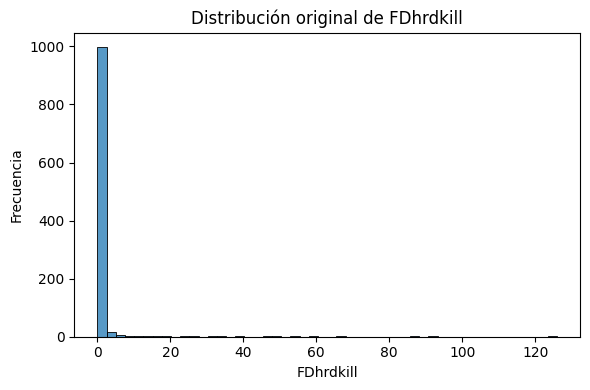

🔍 RMSE: 5.19
🔍 R²: 0.313


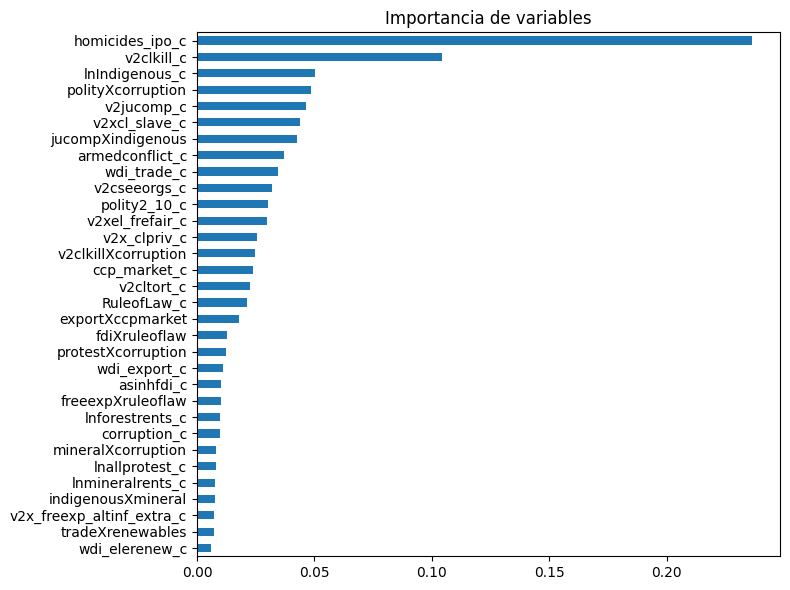

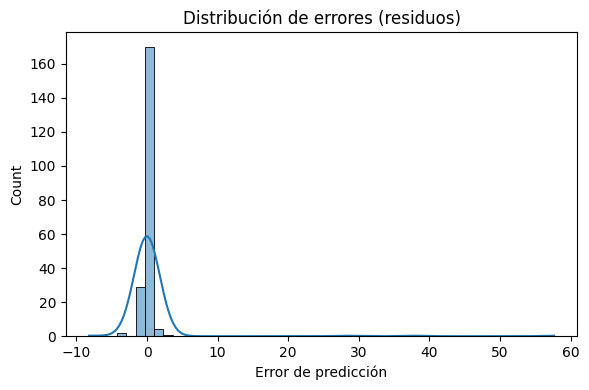

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt


X = df_com_selected[columns_centered_final].copy()
y = df_com_selected["FDhrdkill"]

X = X.replace([np.inf, -np.inf], np.nan)
y = y.replace([np.inf, -np.inf], np.nan)

X = X.fillna(X.mean())
y = y.fillna(y.mean())

plt.figure(figsize=(6, 4))
sns.histplot(y, bins=50, kde=False)
plt.title("Distribución original de FDhrdkill")
plt.xlabel("FDhrdkill")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

y_log = np.log1p(y)  # log(1 + y)

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_log = rf.predict(X_test)


y_pred = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)


rmse = sqrt(mean_squared_error(y_test_real, y_pred))
r2 = r2_score(y_test_real, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")


importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(8, 6), title="Importancia de variables")
plt.tight_layout()
plt.show()

residuals = y_test_real - y_pred
plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Distribución de errores (residuos)")
plt.xlabel("Error de predicción")
plt.tight_layout()
plt.show()


#Final

In [ ]:
print("Variables con VIF aceptable:")
print(X_vif_reducido.columns.tolist())

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import NegativeBinomial
from statsmodels.genmod.cov_struct import Exchangeable

df = df_merged_latam.copy()
df["countrycode"] = df["countrycode"].astype(str)
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

threshold = 0.6
valid_vars = [
    var for var in X_vif_reducido.columns
    if var != "const" and var in df.columns and df[var].notnull().mean() >= threshold
]

X = df[valid_vars].copy()
X = sm.add_constant(X)

X.replace([np.inf, -np.inf], np.nan, inplace=True)
X = X.fillna(X.mean())

y = df["FDhrdkill"].replace([np.inf, -np.inf], np.nan).fillna(df["FDhrdkill"].mean())

mask = X.notnull().all(axis=1) & y.notnull()
X = X[mask]
y = y[mask]
groups = df.loc[mask, "countrycode"].astype(str).to_numpy().ravel()
time = df.loc[mask, "year"].to_numpy().ravel()

print("Observaciones finales:", len(y))
print("Variables incluidas:", X.columns.tolist())

model = GEE(
    endog=y,
    exog=X,
    groups=groups,
    time=time,
    cov_struct=Exchangeable(),
    family=NegativeBinomial()
)

result_gee = model.fit()
print(result_gee.summary())


🧹 Variables con VIF aceptable:
['const', 'lnwdi_gdpcapcon2010_c', 'PTS_S_c', 'totalprotest_c', 'v2cacamps_c', 'v2regimpgroup_c', 'asinhfdi_c', 'lnmineralrents_c', 'lnforestrents_c', 'lnallprotest_c', 'lnhomicides_ipo_c', 'mineralXcorruption', 'protestXpolity', 'fdiXruleoflaw', 'protestXhomicide', 'forestXcorruption', 'protestXmineral', 'fdiXindigenous', 'gdpindXmineral', 'empindXprotests', 'empindXindigenous']
📌 Observaciones finales: 165
📌 Variables incluidas: ['const', 'lnwdi_gdpcapcon2010_c', 'PTS_S_c', 'totalprotest_c', 'v2cacamps_c', 'v2regimpgroup_c', 'asinhfdi_c', 'lnallprotest_c', 'protestXpolity', 'fdiXruleoflaw', 'fdiXindigenous', 'empindXprotests', 'empindXindigenous']
                               GEE Regression Results                              
Dep. Variable:                   FDhrdkill   No. Observations:                  165
Model:                                 GEE   No. clusters:                       33
Method:                        Generalized   Min. cluster s

/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/generalized_estimating_equations.py:1300: IterationLimitWarning: Iteration limit reached prior to convergence
  warnings.warn("Iteration limit reached prior to convergence",


###Significantes NEG BINO america


#Modelo para ver cual es mejor america

In [ ]:
# Comparar Log-Likelihood
print("Log-Likelihood GLM:", result_nbg.llf)
print("Log-Likelihood GEE:", result_gee.llf)

print("AIC GLM:", result_nbg.aic)

if result_nbg.llf > result_gee.llf:
    print("El modelo GLM tiene mejor ajuste (mayor log-likelihood).")
elif result_nbg.llf < result_gee.llf:
    print("El modelo GEE tiene mejor ajuste (mayor log-likelihood).")
else:
    print("Ambos modelos tienen el mismo log-likelihood.")


🔍 Log-Likelihood GLM: -511.4438201034942
🔍 Log-Likelihood GEE: -511.4438201034942
📊 AIC GLM: 1052.8876402069884
⚖️ Ambos modelos tienen el mismo log-likelihood.


#Machine Learning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Cargar tus datos (asegúrate de que ya estén cargados en un DataFrame llamado df)
# Supongamos que:
# - df es tu base de datos
# - y = variable objetivo
# - X = variables explicativas

y = df["FLandmanhrdkill"]
X = df.drop(columns=["FLandmanhrdkill", "countrycode", "year"])  # elimina columnas no explicativas

X = X.replace([np.inf, -np.inf], np.nan)
y = y.replace([np.inf, -np.inf], np.nan)
mask = X.notnull().all(axis=1) & y.notnull()
X = X[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

modelo = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

importancias = pd.Series(modelo.feature_importances_, index=X.columns)
importancias_ordenadas = importancias.sort_values(ascending=True)

importancias_filtradas = importancias_ordenadas[importancias_ordenadas > 0.01]

plt.figure(figsize=(8, 10))
importancias_filtradas.plot(kind='barh')
plt.title("Importancia de variables (Random Forest)")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()


ValueError: With n_samples=0, test_size=0.3 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.